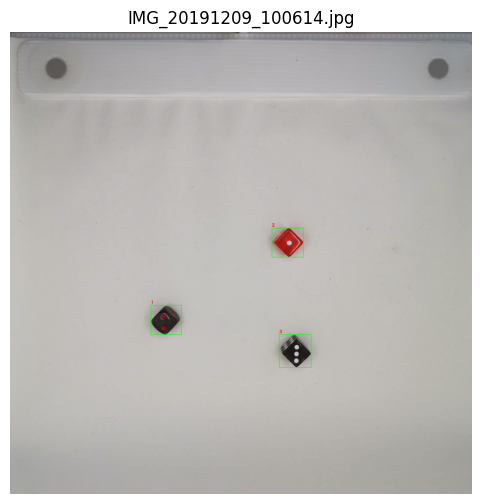

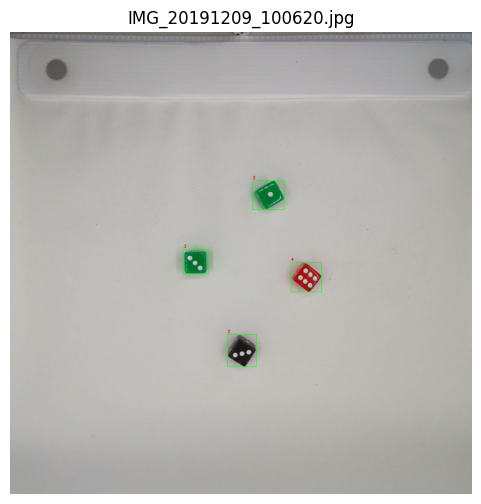

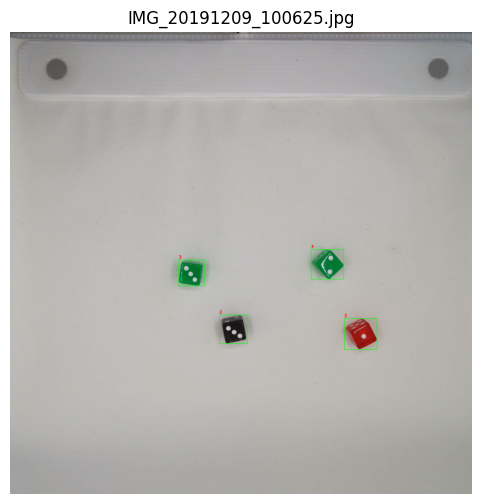

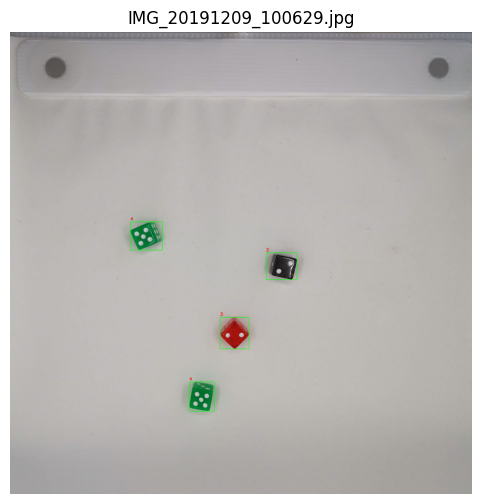

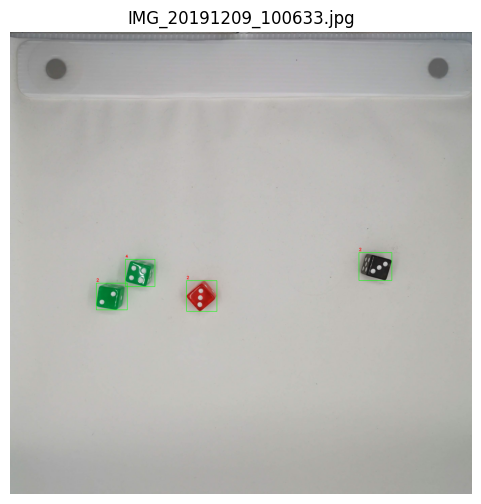

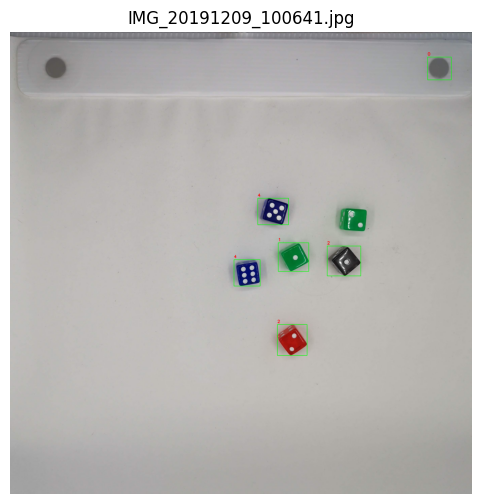

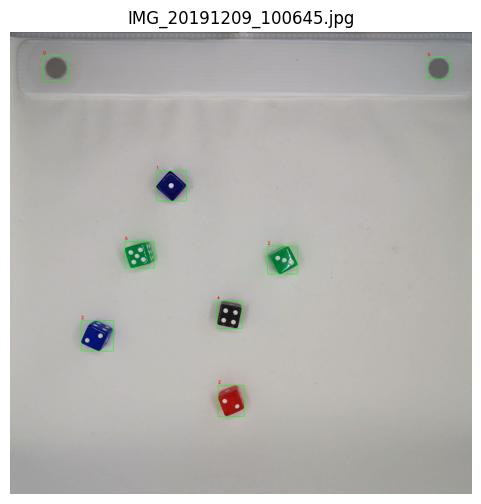

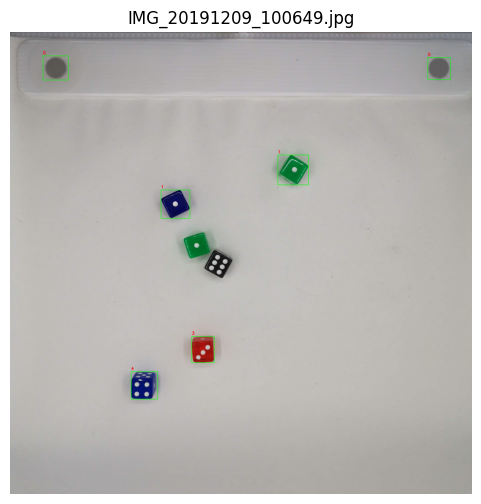

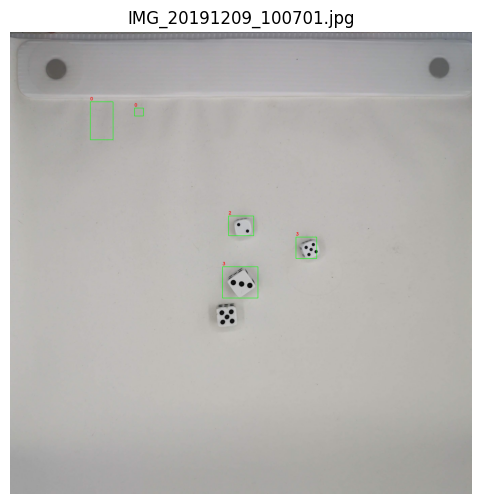

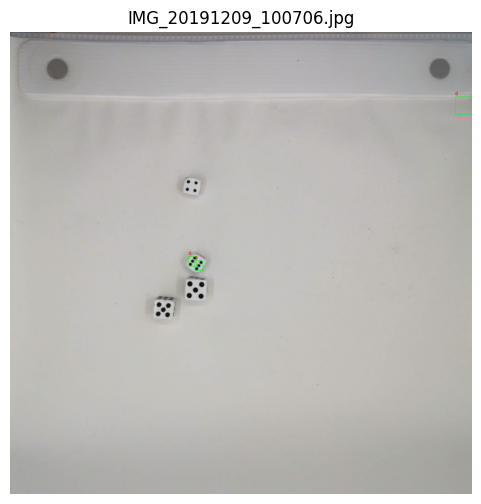

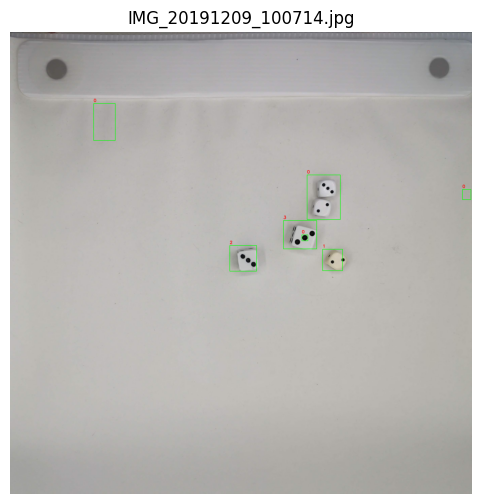

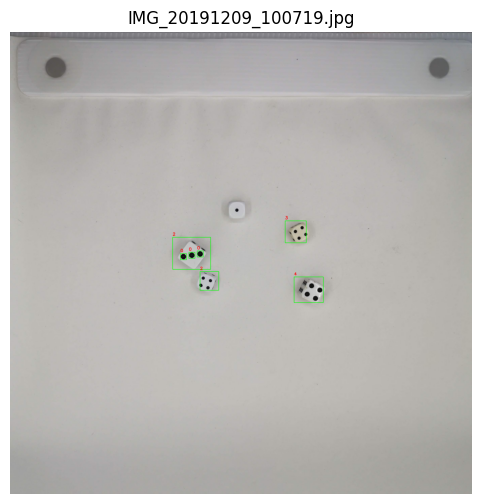

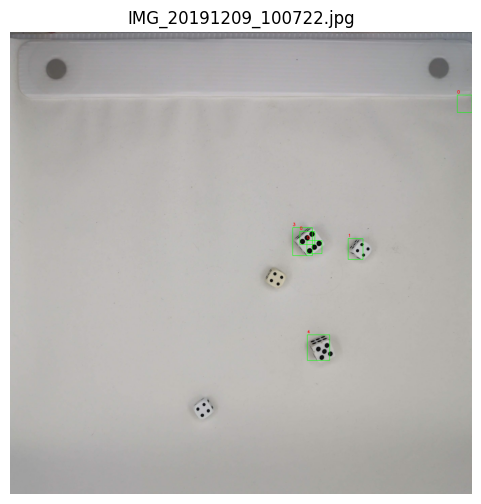

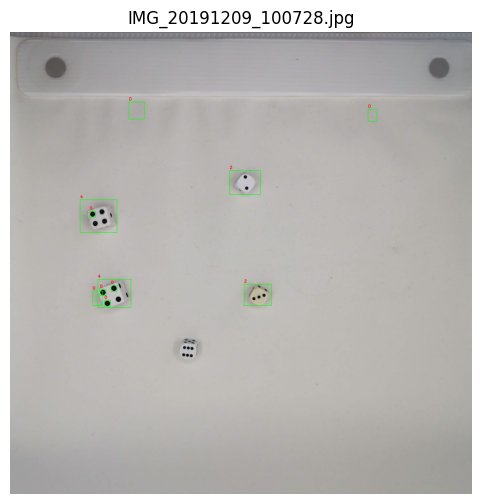

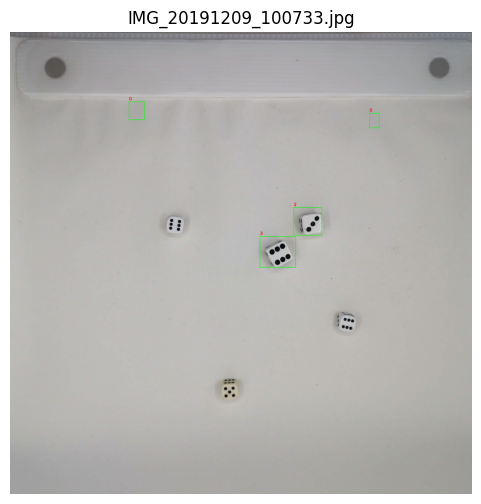

In [ ]:
#Esta es una version reescrita del codigo original prueba2
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

image_folder = "img"

def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (9, 9), 0)  
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th = cv2.bitwise_not(th)
    kernel = np.ones((3, 3), np.uint8)
    close = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)
    return close

def detect_dice(binary):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)
    dice_boxes = []
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < 1000 or area > 30000:  
            continue
            
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        
        ratio = w / float(h)
        if ratio < 0.5 or ratio > 1.3:  
            continue
            
        dice_boxes.append((x, y, w, h))
    
    return sorted(dice_boxes, key=lambda b: (b[1], b[0]))

def detect_dots(roi):
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (11, 11), 2)  
    
    h, w = gray.shape
    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=min(h, w) / 3,  
        param1=65,  
        param2=20,  
        minRadius=int(min(h, w) * 0.08),
        maxRadius=int(min(h, w) * 0.20)
    )
    
    return min(len(circles[0]), 6) if circles is not None else 0

def process_image(path):
    img = cv2.imread(path)
    binary = preprocess(img)
    dice_boxes = detect_dice(binary)
    
    values = []
    for (x, y, w, h) in dice_boxes:
        margin = int(0.10 * min(w, h))  
        roi = img[y + margin:y + h - margin, x + margin:x + w - margin]
        
        dots = detect_dots(roi)
        values.append(dots)
        
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(
            img,
            str(dots),
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2
        )
    
    
    values = [min(v, 6) for v in values]
    
   
    valid_dice = [v for v in values if v >= 1]
    
    return img, len(valid_dice), valid_dice


def read_annotation(file):
    with open(file) as f:
        lines = f.readlines()
    
    real_faces = []
    for line in lines:
        parts = line.strip().split()
        face = int(parts[0])
        real_faces.append(face)
    
    real_dice = len(real_faces)
    return real_dice, real_faces


results = []

for file in os.listdir(image_folder):
    path = os.path.join(image_folder, file)
    img_out, dice_count, values = process_image(path)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))
    plt.title(file)
    plt.axis("off")
    plt.show()
    
    results.append({
        "image": file,
        "detected_dice": dice_count,
        "detected_faces": values
    })